In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [2]:
data = {
    "Area": [1000, 1200, 1500, 1800, 2000, 2200, 2500, 2800, 3000, 3500],
    "Bedrooms": [2, 2, 3, 3, 4, 4, 4, 5, 5, 6],
    "Age": [15, 12, 10, 8, 7, 6, 5, 4, 3, 2],
    "Price": [3000000, 3500000, 4500000, 5200000, 6000000,
              6500000, 7200000, 8000000, 8500000, 9500000]
}

df = pd.DataFrame(data)

print(df)

   Area  Bedrooms  Age    Price
0  1000         2   15  3000000
1  1200         2   12  3500000
2  1500         3   10  4500000
3  1800         3    8  5200000
4  2000         4    7  6000000
5  2200         4    6  6500000
6  2500         4    5  7200000
7  2800         5    4  8000000
8  3000         5    3  8500000
9  3500         6    2  9500000


In [4]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Area      10 non-null     int64
 1   Bedrooms  10 non-null     int64
 2   Age       10 non-null     int64
 3   Price     10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


,Area,Bedrooms,Age,Price
count,10.000000,10.000000,10.000000,1.000000e+01
mean,2150.000000,3.800000,7.200000,6.190000e+06
std,808.633965,1.316561,4.131182,2.159450e+06
min,1000.000000,2.000000,2.000000,3.000000e+06
25%,1575.000000,3.000000,4.250000,4.675000e+06
50%,2100.000000,4.000000,6.500000,6.250000e+06
75%,2725.000000,4.750000,9.500000,7.800000e+06
max,3500.000000,6.000000,15.000000,9.500000e+06


In [5]:
X = df.drop("Price", axis=1)

y = df["Price"]

print("Features (X):")
print(X)

print("\nTarget (y):")
print(y)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features (X):
   Area  Bedrooms  Age
0  1000         2   15
1  1200         2   12
2  1500         3   10
3  1800         3    8
4  2000         4    7
5  2200         4    6
6  2500         4    5
7  2800         5    4
8  3000         5    3
9  3500         6    2

Target (y):
0    3000000
1    3500000
2    4500000
3    5200000
4    6000000
5    6500000
6    7200000
7    8000000
8    8500000
9    9500000
Name: Price, dtype: int64

X shape: (10, 3)
y shape: (10,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8, 3)
X_test shape: (2, 3)
y_train shape: (8,)
y_test shape: (2,)


In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [8]:
y_pred = model.predict(X_test)

print("Predicted Prices:")
print(y_pred)

print("\nActual Prices:")
print(y_test.values)

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print("\nComparison Table:")
print(comparison)

Predicted Prices:
[8396470.98289165 3634330.76148943]

Actual Prices:
[8500000 3500000]

Comparison Table:
   Actual Price  Predicted Price
0       8500000     8.396471e+06
1       3500000     3.634331e+06


In [9]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance Summary")
print("-" * 30)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Model Performance Summary
------------------------------
MAE : 118929.88929889398
RMSE: 119922.91454462113
R² Score: 0.9976989591307398


Residuals:
8    103529.017108
1   -134330.761489
Name: Price, dtype: float64


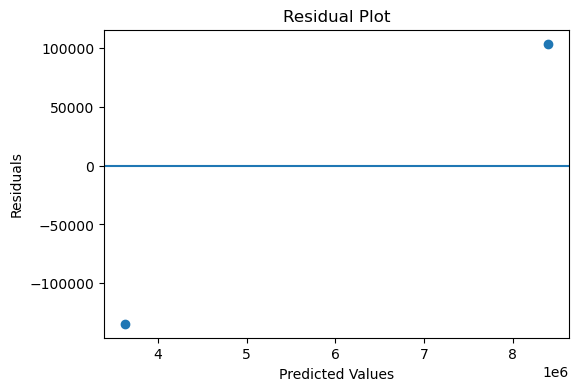

In [11]:
residuals = y_test - y_pred

print("Residuals:")
print(residuals)

plt.figure(figsize=(6, 4))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [12]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Feature Drivers:")
print(coefficients)

Feature Drivers:
    Feature    Coefficient
0      Area    1804.226770
1  Bedrooms  184917.812814
2       Age -106642.066421


In [13]:
print("\n===== LINEAR REGRESSION METRICS SUMMARY =====")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

print("\n===== DRIVER ANALYSIS =====")
print(coefficients)


===== LINEAR REGRESSION METRICS SUMMARY =====
MAE : 118929.88929889398
RMSE: 119922.91454462113
R² Score: 0.9976989591307398

===== DRIVER ANALYSIS =====
    Feature    Coefficient
0      Area    1804.226770
1  Bedrooms  184917.812814
2       Age -106642.066421


# Conclusion

A Linear Regression model was built to predict house prices using Area, Bedrooms, and Age.

The model was evaluated using:
- MAE
- RMSE
- R² Score

Residual analysis was performed to inspect prediction errors.

Feature coefficients were analyzed to identify the key drivers affecting house prices.

The task requirements for Linear Regression were successfully completed.